# Teste Básico com os Filtros

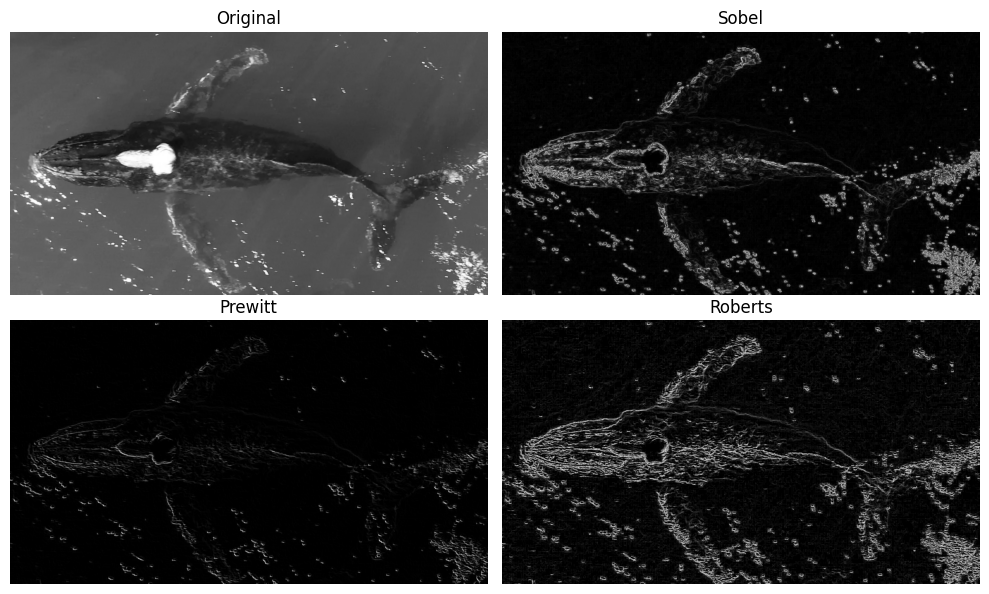

In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# Caminho da pasta
pasta = "Teste"

# Percorre todos os arquivos da pasta
for arquivo in os.listdir(pasta):
    caminho_imagem = os.path.join(pasta, arquivo)

    # Verifica se é imagem
    if not (arquivo.lower().endswith((".png", ".jpg", ".jpeg"))):
        continue

    # Carrega a imagem
    img = cv2.imread(caminho_imagem)
    if img is None:
        continue

    # Pré-processamento
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag = cv2.magnitude(sobelx, sobely)
    sobel_final = np.uint8(np.absolute(sobel_mag))

    kernelx = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
    kernely = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
    prewitt_x = cv2.filter2D(img_gray, -1, kernelx)
    prewitt_y = cv2.filter2D(img_gray, -1, kernely)
    prewitt_final = cv2.addWeighted(prewitt_x, 0.5, prewitt_y, 0.5, 0)

    k_roberts_x = np.array([[1, 0], [0, -1]], dtype=np.float32)
    k_roberts_y = np.array([[0, 1], [-1, 0]], dtype=np.float32)
    gx = cv2.filter2D(img_gray, -1, k_roberts_x)
    gy = cv2.filter2D(img_gray, -1, k_roberts_y)
    roberts_final = np.uint8(np.sqrt(np.square(gx) + np.square(gy)))

    plt.figure(figsize=(10, 6))

    # Original
    plt.subplot(2, 2, 1)
    plt.imshow(img_gray, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Sobel
    plt.subplot(2, 2, 2)
    plt.imshow(sobel_final, cmap='gray')
    plt.title("Sobel")
    plt.axis('off')

    # Prewitt
    plt.subplot(2, 2, 3)
    plt.imshow(prewitt_final, cmap='gray')
    plt.title("Prewitt")
    plt.axis('off')

    # Roberts
    plt.subplot(2, 2, 4)
    plt.imshow(roberts_final, cmap='gray')
    plt.title("Roberts")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Teste com redução de ruído

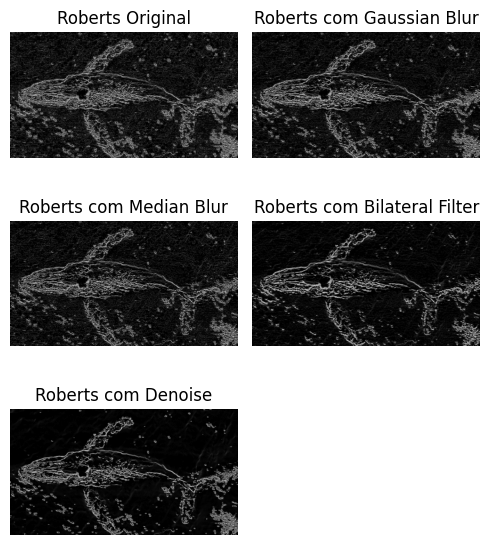

In [2]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# Caminho da pasta
pasta = "Teste"

# Percorre todos os arquivos da pasta
for arquivo in os.listdir(pasta):
    caminho_imagem = os.path.join(pasta, arquivo)

    # Verifica se é imagem
    if not (arquivo.lower().endswith((".png", ".jpg", ".jpeg"))):
        continue

    # Carrega a imagem
    img = cv2.imread(caminho_imagem)
    if img is None:
        continue

    # Pré-processamento
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)
    img_gaussian = cv2.GaussianBlur(img, (3, 3), 0)
    img_median = cv2.medianBlur(img, 3)
    img_bilateral = cv2.bilateralFilter(img, 9, 75, 75)
    img_denoised = cv2.fastNlMeansDenoising(img, None, h=10, templateWindowSize=7, searchWindowSize=21)

    k_roberts_x = np.array([[1, 0], [0, -1]], dtype=np.float32)
    k_roberts_y = np.array([[0, 1], [-1, 0]], dtype=np.float32)
    gx = cv2.filter2D(img, -1, k_roberts_x)
    gy = cv2.filter2D(img, -1, k_roberts_y)
    roberts = np.uint8(np.sqrt(np.square(gx) + np.square(gy)))

    gx = cv2.filter2D(img_gaussian, -1, k_roberts_x)
    gy = cv2.filter2D(img_gaussian, -1, k_roberts_y)
    roberts_gaussian = np.uint8(np.sqrt(np.square(gx) + np.square(gy)))

    gx = cv2.filter2D(img_median, -1, k_roberts_x)
    gy = cv2.filter2D(img_median, -1, k_roberts_y)
    roberts_median = np.uint8(np.sqrt(np.square(gx) + np.square(gy)))

    gx = cv2.filter2D(img_bilateral, -1, k_roberts_x)
    gy = cv2.filter2D(img_bilateral, -1, k_roberts_y)
    roberts_bilateral = np.uint8(np.sqrt(np.square(gx) + np.square(gy)))

    gx = cv2.filter2D(img_denoised, -1, k_roberts_x)
    gy = cv2.filter2D(img_denoised, -1, k_roberts_y)
    roberts_denoised = np.uint8(np.sqrt(np.square(gx) + np.square(gy)))
    plt.figure(figsize=(5, 6))

    # Original
    plt.subplot(3, 2, 1)
    plt.imshow(roberts, cmap='gray')
    plt.title("Roberts Original")
    plt.axis('off')

    # Sobel
    plt.subplot(3, 2, 2)
    plt.imshow(roberts_gaussian, cmap='gray')
    plt.title("Roberts com Gaussian Blur")
    plt.axis('off')

    # Prewitt
    plt.subplot(3, 2, 3)
    plt.imshow(roberts_median, cmap='gray')
    plt.title("Roberts com Median Blur")
    plt.axis('off')

    # Roberts
    plt.subplot(3, 2, 4)
    plt.imshow(roberts_bilateral, cmap='gray')
    plt.title("Roberts com Bilateral Filter")
    plt.axis('off')

    plt.subplot(3, 2, 5)
    plt.imshow(roberts_denoised, cmap='gray')
    plt.title("Roberts com Denoise")
    plt.axis('off')


    plt.tight_layout()
    plt.show()

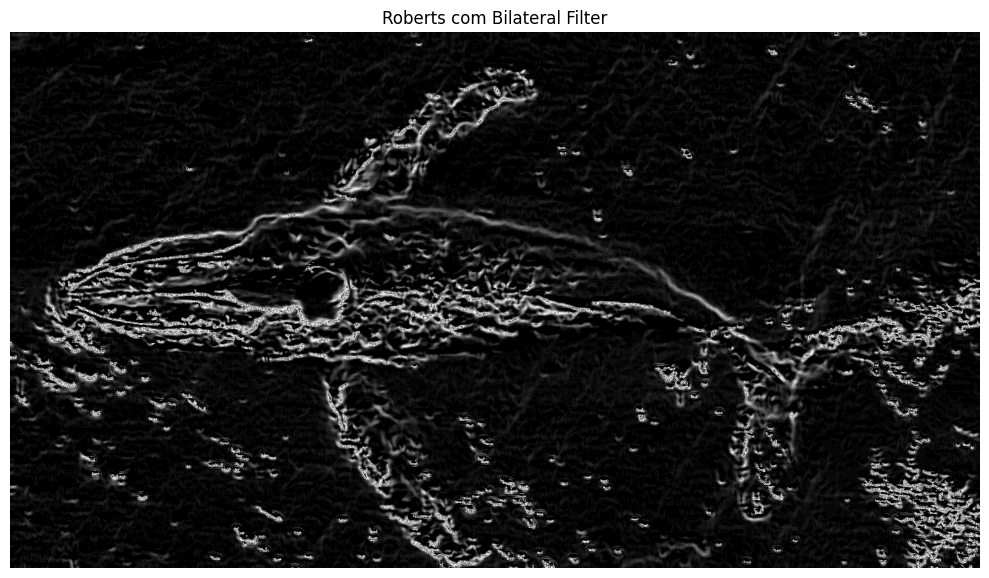

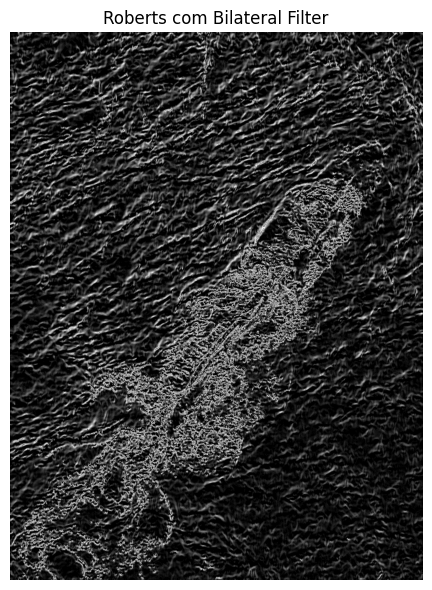

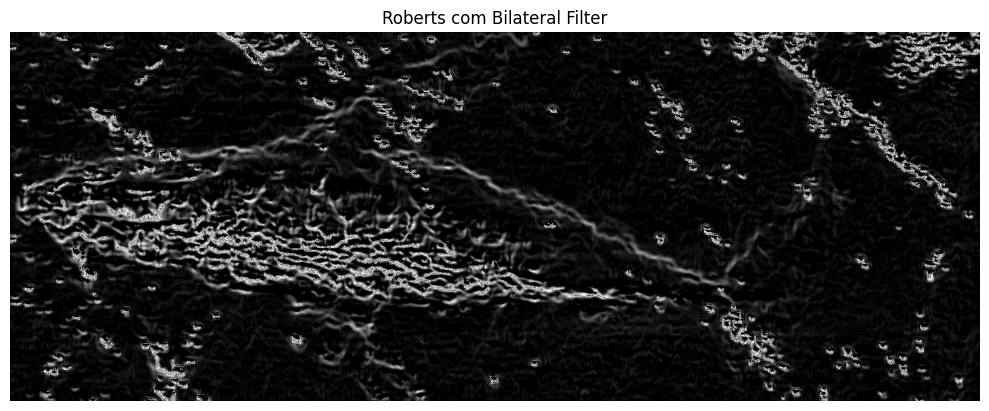

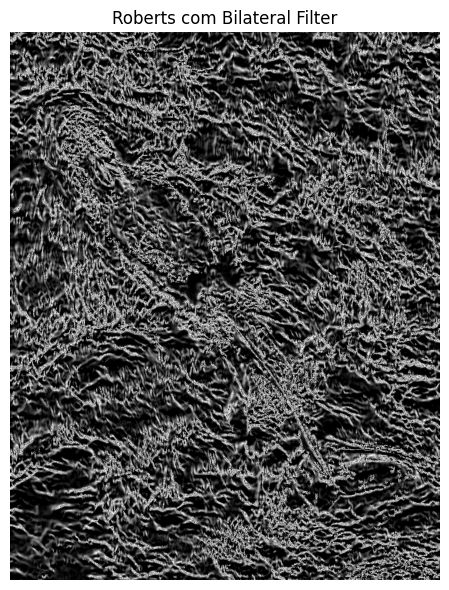

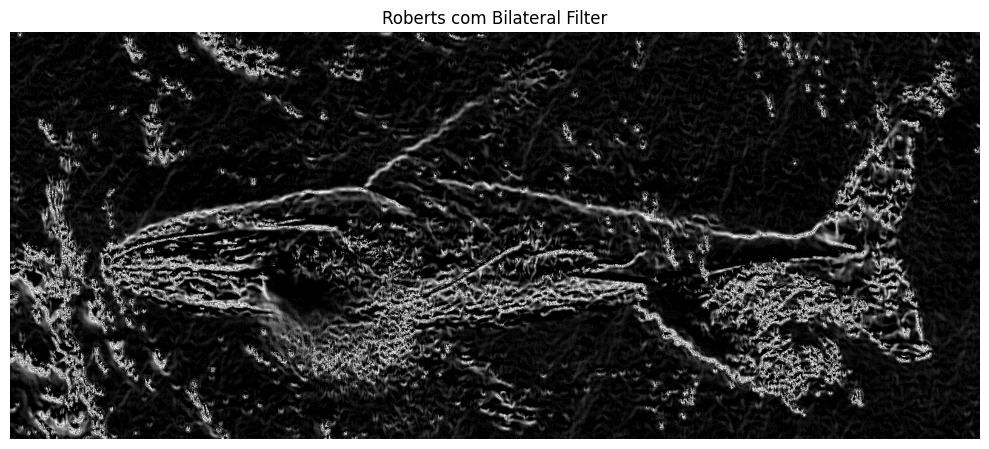

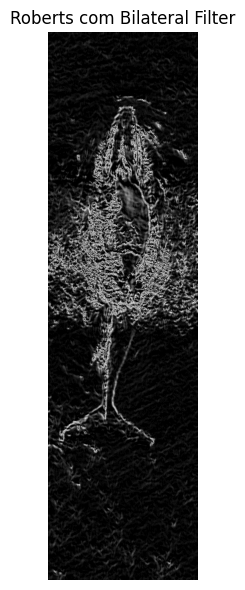

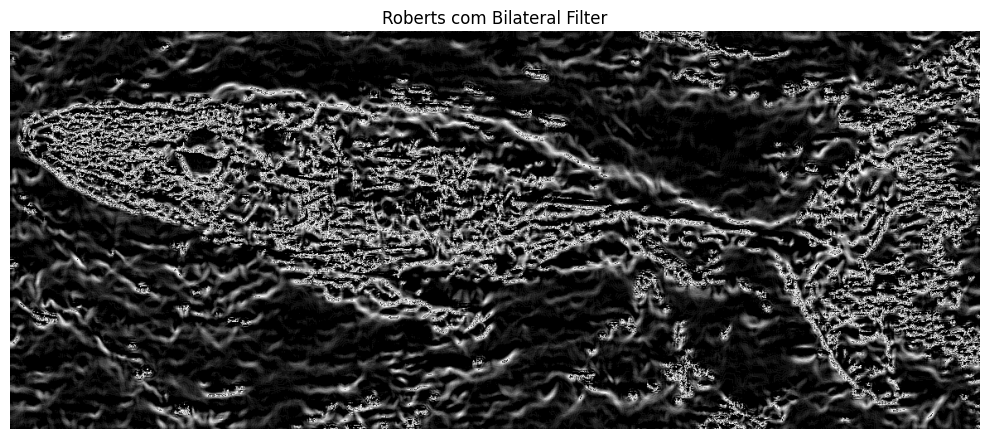

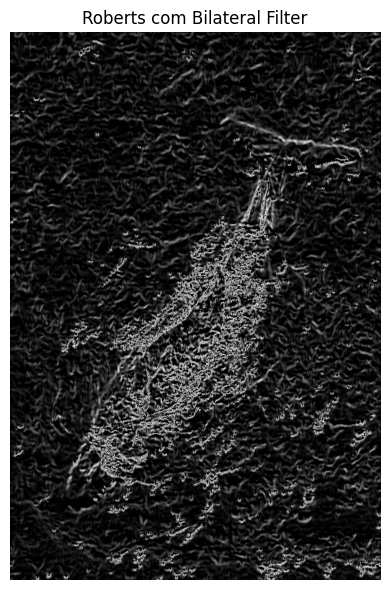

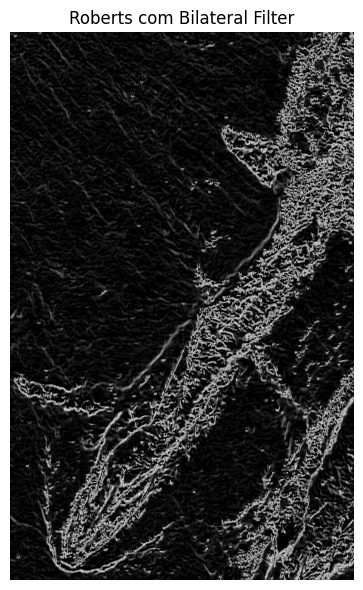

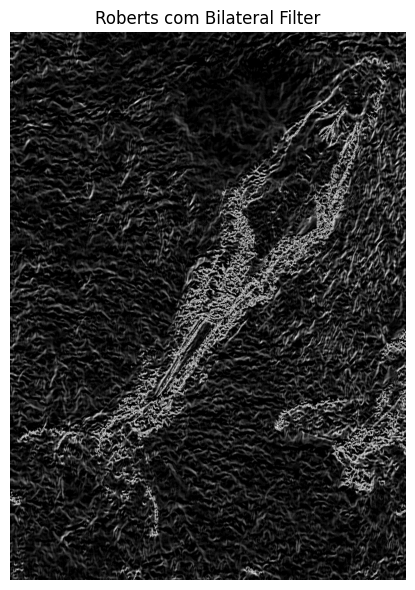

In [6]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# Caminho da pasta
pasta = "Teste_Frames"

# Percorre todos os arquivos da pasta
for arquivo in os.listdir(pasta):
    caminho_imagem = os.path.join(pasta, arquivo)

    # Verifica se é imagem
    if not (arquivo.endswith(".png") or arquivo.endswith(".jpg") or arquivo.endswith(".jpeg")):
        continue

    # Carrega a imagem
    img = cv2.imread(caminho_imagem)
    if img is None:
        continue

    # Pré-processamento
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)
    img_bilateral = cv2.bilateralFilter(img, 9, 75, 75)

    gx = cv2.filter2D(img_bilateral, -1, k_roberts_x)
    gy = cv2.filter2D(img_bilateral, -1, k_roberts_y)
    roberts_bilateral = np.uint8(np.sqrt(np.square(gx) + np.square(gy)))
    
    plt.figure(figsize=(10, 6))

    # Roberts
    plt.imshow(roberts_bilateral, cmap='gray')
    plt.title("Roberts com Bilateral Filter")
    plt.axis('off')
    plt.tight_layout()
    plt.show()